# Startup Dataset Analysis
Workflow: **Load clean data → intentionally dirty it → clean it back → analyze & visualize.**

This mirrors a real-world scenario where you practice data-cleaning skills on data you
know the "ground truth" of, then confirm your cleaning pipeline actually fixes it.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)

# Show big numbers as readable numbers (e.g. 9,072,222) instead of
# pandas' default scientific notation (e.g. 9.072222e+06)
pd.options.display.float_format = "{:,.0f}".format

## 1. Load the (Clean) Data

In [2]:
df = pd.read_csv("Startup Dataset.csv")
df.head()

,Name,Country,Description,Launch Date,Founders,Revenue Year 1,Revenue Year 2,Revenue Year 3,Current Status
0,SpaceX,USA,Aerospace manufacturer and space transport.,2002-03-14,Elon Musk,$0,$0,$0,Successful
1,Stripe,USA,Online payment processing.,2011-09-29,"Patrick Collison, John Collison",$0,$0,$10M,Successful
2,Airbnb,USA,Vacation rentals and homestays.,2008-08-01,"Brian Chesky, Joe Gebbia, Nathan Blecharczyk",$0,$1M,$8.4M,Successful
3,Uber,USA,Ride-hailing and food delivery.,2009-03-01,"Travis Kalanick, Garrett Camp",$0,$0,$0.5M,Successful
4,Canva,Australia,Graphic design platform.,2013-01-01,"Melanie Perkins, Cliff Obrecht, Cameron Adams",$0,$1M,$2M,Successful


### 1.1 Confirm It's Clean Before We Touch It

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Shape: (1050, 9)

Missing values:
 Name              0
Country           0
Description       0
Launch Date       0
Founders          0
Revenue Year 1    0
Revenue Year 2    0
Revenue Year 3    0
Current Status    0
dtype: int64

Duplicate rows: 0

Dtypes:
 Name              str
Country           str
Description       str
Launch Date       str
Founders          str
Revenue Year 1    str
Revenue Year 2    str
Revenue Year 3    str
Current Status    str
dtype: object


## 2. Intentionally Dirty the Data

We now corrupt a *copy* of the clean data on purpose, the same way real messy data shows up:
- Duplicate rows
- Missing values (`NaN`) scattered across columns
- Inconsistent whitespace / casing in text columns
- Inconsistent data types within the same column

In [4]:
df_dirty = df.copy()

# 2.1 Add duplicate rows
dupes = df_dirty.sample(20, random_state=1)
df_dirty = pd.concat([df_dirty, dupes], ignore_index=True)
print("Rows after adding duplicates:", df_dirty.shape[0])

Rows after adding duplicates: 1070


In [5]:
# 2.2 Inject missing values (NaN) into several columns
for col, n in [("Country", 15), ("Founders", 12), ("Current Status", 10), ("Revenue Year 2", 18)]:
    idx = df_dirty.sample(n, random_state=2).index
    df_dirty.loc[idx, col] = np.nan

df_dirty.isnull().sum()

Name               0
Country           15
Description        0
Launch Date        0
Founders          12
Revenue Year 1     0
Revenue Year 2    18
Revenue Year 3     0
Current Status    10
dtype: int64

In [6]:
# 2.3 Add messy whitespace and inconsistent casing to text columns
idx_upper = df_dirty.sample(30, random_state=3).index
idx_lower = df_dirty.sample(30, random_state=4).index
idx_space = df_dirty.sample(40, random_state=5).index

df_dirty.loc[idx_upper, "Country"] = df_dirty.loc[idx_upper, "Country"].str.upper()
df_dirty.loc[idx_lower, "Country"] = df_dirty.loc[idx_lower, "Country"].str.lower()
df_dirty.loc[idx_space, "Name"] = "   " + df_dirty.loc[idx_space, "Name"].astype(str) + "   "

df_dirty[["Name", "Country"]].sample(10, random_state=6)

,Name,Country
966,Smart Cybersecurity Labs 966,Israel
269,NextGen AgriTech Wave 269,Israel
461,Zenith HealthTech Hub 461,Australia
207,Apex SaaS Labs 207,USA
686,Quantum AgriTech Network 686,Israel
808,Zenith AI/ML Labs 808,India
712,Elite BioTech Wave 712,Brazil
152,Core EdTech Network 152,South Korea
1023,Global PropTech Solutions 1023,USA
55,Quantum Logistics Flow 55,South Korea


In [7]:
# 2.4 Corrupt data types within a single column
# Revenue Year 1 should be text like "$1M" -- replace a subset with raw floats instead
# (cast to object dtype first so the column can legally hold mixed str/float values)
df_dirty["Revenue Year 1"] = df_dirty["Revenue Year 1"].astype(object)
idx_type = df_dirty.sample(25, random_state=7).index

def to_raw_float(x):
    x = str(x).replace("$", "")
    if x.upper().endswith("M"):
        return float(x[:-1]) * 1_000_000
    if x.lower().endswith("k"):
        return float(x[:-1]) * 1_000
    return float(x)

df_dirty.loc[idx_type, "Revenue Year 1"] = df_dirty.loc[idx_type, "Revenue Year 1"].apply(to_raw_float)

# Launch Date should be a consistent yyyy-mm-dd string -- reformat a subset to dd/mm/yyyy
idx_date = df_dirty.sample(20, random_state=8).index
df_dirty.loc[idx_date, "Launch Date"] = pd.to_datetime(
    df_dirty.loc[idx_date, "Launch Date"]
).dt.strftime("%d/%m/%Y")

print(df_dirty["Revenue Year 1"].apply(type).value_counts())
print(df_dirty["Launch Date"].sample(10, random_state=9).tolist())

Revenue Year 1
<class 'str'>      1045
<class 'float'>      25
Name: count, dtype: int64
['2017-10-18', '2022-09-02', '2011-05-28', '2013-12-12', '2011-04-17', '2011-11-14', '2012-03-24', '2019-09-06', '2019-08-04', '2019-05-03']


## 3. Inspect the Dirty Data

In [8]:
print("Shape:", df_dirty.shape)
print("\nMissing values:\n", df_dirty.isnull().sum())
print("\nDuplicate rows:", df_dirty.duplicated().sum())

Shape: (1070, 9)

Missing values:
 Name               0
Country           15
Description        0
Launch Date        0
Founders          12
Revenue Year 1     0
Revenue Year 2    18
Revenue Year 3     0
Current Status    10
dtype: int64

Duplicate rows: 14


In [9]:
df_dirty.sample(10, random_state=10)

,Name,Country,Description,Launch Date,Founders,Revenue Year 1,Revenue Year 2,Revenue Year 3,Current Status
619,Smart HealthTech Labs 619,Canada,A leading Canada-based HealthTech startup spec...,2019-07-25,"Aisha Khan, Sarah Jenkins, David Chen",$41k,$185k,$7.7M,Acquired
326,Apex SaaS Wave 326,Singapore,A leading Singapore-based SaaS startup special...,2011-10-28,"Anjali Rao, Aisha Khan, Emma Wilson",$337k,$1.5M,$11.5M,Successful
64,Zenith AgriTech Wave 64,Japan,A leading Japan-based AgriTech startup special...,2015-04-13,"Li Wei, Vikram Singh",$453k,$2.0M,$14.1M,Acquired
399,NextGen PropTech Systems 399,Japan,A leading Japan-based PropTech startup special...,2013-02-16,Anjali Rao,$129k,$258k,$13.1M,Failed
912,Apex BioTech Wave 912,UAE,A leading UAE-based BioTech startup specializi...,2019-12-20,Sarah Jenkins,$178k,$523k,$1.2M,Acquired
592,Apex SaaS Labs 592,France,A leading France-based SaaS startup specializi...,2015-04-22,"Priya Sharma, Sarah Jenkins, Anjali Rao",$306k,$263k,$14.3M,Acquired
74,Smart BioTech Network 74,Australia,A leading Australia-based BioTech startup spec...,2021-11-25,"Kavita Reddy, Michael O'Connor, Arjun Mehta",$324k,$1.8M,$13.0M,Successful
387,NextGen AI/ML Wave 387,Japan,A leading Japan-based AI/ML startup specializi...,2020-12-14,Rohan Das,$173k,$541k,$7.2M,Successful
751,Global BioTech Labs 751,singapore,A leading Singapore-based BioTech startup spec...,2018-05-19,"Priya Sharma, Li Wei",$236k,$1.3M,$12.2M,Acquired
1064,Global Cybersecurity Hub 800,Singapore,A leading Singapore-based Cybersecurity startu...,2022-09-28,David Chen,$273k,$792k,$2.3M,Successful


## 4. Clean the Data Back Up

Now we reverse every issue we introduced above, step by step.

In [10]:
df_clean = df_dirty.copy()

# 4.1 Remove duplicate rows
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df_clean.shape[0]} duplicate rows")

Removed 14 duplicate rows


In [11]:
# 4.2 Fix whitespace and inconsistent casing in text columns
df_clean["Name"] = df_clean["Name"].astype(str).str.strip()
df_clean["Country"] = df_clean["Country"].astype(str).str.strip().str.title()
df_clean[["Name", "Country"]].sample(10, random_state=6)

,Name,Country
899,Quantum PropTech Network 899,France
568,Zenith Cybersecurity Flow 568,Uk
658,Zenith PropTech Solutions 658,Japan
80,Global CleanTech Flow 80,South Korea
687,Nova Logistics Network 687,Canada
1036,Smart CleanTech Solutions 1036,Uk
842,Global AgriTech Hub 842,India
694,Nova PropTech Wave 694,Brazil
179,Apex SaaS Network 179,Uae
223,Apex AI/ML Wave 223,Brazil


In [12]:
# 4.3 Handle missing values
# Categorical columns -> fill with the most frequent value (mode)
for col in ["Country", "Founders", "Current Status"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Revenue Year 2 is numeric-ish text -> fill missing with "$0" (no reported revenue)
df_clean["Revenue Year 2"] = df_clean["Revenue Year 2"].fillna("$0")

df_clean.isnull().sum()

Name              0
Country           0
Description       0
Launch Date       0
Founders          0
Revenue Year 1    0
Revenue Year 2    0
Revenue Year 3    0
Current Status    0
dtype: int64

In [13]:
# 4.4 Fix inconsistent data types
def parse_money(value):
    """Convert '$0' / '$1M' / '$80k' / a raw float into a numeric USD amount."""
    if isinstance(value, (int, float)):
        return float(value)
    value = str(value).replace("$", "").strip()
    if value.upper().endswith("M"):
        return float(value[:-1]) * 1_000_000
    if value.lower().endswith("k"):
        return float(value[:-1]) * 1_000
    return float(value)

for col in ["Revenue Year 1", "Revenue Year 2", "Revenue Year 3"]:
    df_clean[col + " (USD)"] = df_clean[col].apply(parse_money)

# Launch Date had two different formats -> parse both with a consistent result
df_clean["Launch Date"] = pd.to_datetime(df_clean["Launch Date"], format="mixed", dayfirst=False)
df_clean["Launch Year"] = df_clean["Launch Date"].dt.year

df_clean[["Revenue Year 1", "Revenue Year 1 (USD)", "Launch Date", "Launch Year"]].head()

,Revenue Year 1,Revenue Year 1 (USD),Launch Date,Launch Year
0,$0,0,2002-03-14,2002
1,$0,0,2011-09-29,2011
2,$0,0,2008-08-01,2008
3,$0,0,2009-03-01,2009
4,$0,0,2013-01-01,2013


### 4.5 Confirm the Cleaning Worked

In [14]:
print("Shape:", df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())
print("\nDuplicate rows:", df_clean.duplicated().sum())
print("\nDtypes:\n", df_clean.dtypes)

Shape: (1056, 13)

Missing values:
 Name                    0
Country                 0
Description             0
Launch Date             0
Founders                0
Revenue Year 1          0
Revenue Year 2          0
Revenue Year 3          0
Current Status          0
Revenue Year 1 (USD)    0
Revenue Year 2 (USD)    0
Revenue Year 3 (USD)    0
Launch Year             0
dtype: int64

Duplicate rows: 5

Dtypes:
 Name                               str
Country                            str
Description                        str
Launch Date             datetime64[us]
Founders                           str
Revenue Year 1                  object
Revenue Year 2                     str
Revenue Year 3                     str
Current Status                     str
Revenue Year 1 (USD)           float64
Revenue Year 2 (USD)           float64
Revenue Year 3 (USD)           float64
Launch Year                      int32
dtype: object


## 5. Feature Engineering

In [15]:
df_clean["Founder Count"] = df_clean["Founders"].apply(lambda x: len(str(x).split(",")))
df_clean["Total Revenue (USD)"] = (
    df_clean["Revenue Year 1 (USD)"] + df_clean["Revenue Year 2 (USD)"] + df_clean["Revenue Year 3 (USD)"]
)
df_clean["Revenue Growth (Y1->Y3)"] = df_clean["Revenue Year 3 (USD)"] - df_clean["Revenue Year 1 (USD)"]
df_clean.head()

,Name,Country,Description,Launch Date,Founders,Revenue Year 1,Revenue Year 2,Revenue Year 3,Current Status,Revenue Year 1 (USD),Revenue Year 2 (USD),Revenue Year 3 (USD),Launch Year,Founder Count,Total Revenue (USD),Revenue Growth (Y1->Y3)
0,SpaceX,Usa,Aerospace manufacturer and space transport.,2002-03-14,Elon Musk,$0,$0,$0,Successful,0,0,0,2002,1,0,0
1,Stripe,Usa,Online payment processing.,2011-09-29,"Patrick Collison, John Collison",$0,$0,$10M,Successful,0,0,"10,000,000",2011,2,"10,000,000","10,000,000"
2,Airbnb,Usa,Vacation rentals and homestays.,2008-08-01,"Brian Chesky, Joe Gebbia, Nathan Blecharczyk",$0,$1M,$8.4M,Successful,0,"1,000,000","8,400,000",2008,3,"9,400,000","8,400,000"
3,Uber,Usa,Ride-hailing and food delivery.,2009-03-01,"Travis Kalanick, Garrett Camp",$0,$0,$0.5M,Successful,0,0,"500,000",2009,2,"500,000","500,000"
4,Canva,Australia,Graphic design platform.,2013-01-01,"Melanie Perkins, Cliff Obrecht, Cameron Adams",$0,$1M,$2M,Successful,0,"1,000,000","2,000,000",2013,3,"3,000,000","2,000,000"


In [16]:
# Use df_clean for everything from here on
df = df_clean.copy()

## 6. Pivot Tables & Aggregations

In [17]:
pd.pivot_table(df, index="Country", values="Name", aggfunc="count") \
  .rename(columns={"Name": "Startup Count"}) \
  .sort_values("Startup Count", ascending=False)

,Startup Count
Country,
Uae,112
Usa,89
Japan,88
Singapore,87
Australia,82
Israel,82
Canada,81
Brazil,80
India,77


In [18]:
pd.pivot_table(df, index="Current Status", values="Name", aggfunc="count") \
  .rename(columns={"Name": "Startup Count"})

,Startup Count
Current Status,
Acquired,207
Failed,131
Successful,718


In [19]:
pd.pivot_table(df, index="Country", values="Revenue Year 3 (USD)", aggfunc="mean") \
  .sort_values("Revenue Year 3 (USD)", ascending=False)

,Revenue Year 3 (USD)
Country,
Uk,"9,072,222"
South Korea,"8,827,778"
France,"8,580,882"
Germany,"8,203,030"
Usa,"8,160,674"
Israel,"8,080,488"
Singapore,"8,065,517"
Uae,"8,029,464"
Canada,"7,892,593"


**Note:** values like `9.072222e+06` are not an error -- that is just pandas'
default scientific notation for large floats (it equals 9,072,222). The
`pd.options.display.float_format` line set near the top of this notebook makes every
DataFrame below (and above, on re-run) display large numbers with commas instead.

### Average Revenue by Country -- Year 1, Year 2, and Year 3 Together

In [20]:
pd.pivot_table(
    df,
    index="Country",
    values=["Revenue Year 1 (USD)", "Revenue Year 2 (USD)", "Revenue Year 3 (USD)"],
    aggfunc="mean"
).sort_values("Revenue Year 3 (USD)", ascending=False)

,Revenue Year 1 (USD),Revenue Year 2 (USD),Revenue Year 3 (USD)
Country,,,
Uk,"253,833","1,099,639","9,072,222"
South Korea,"241,264","897,958","8,827,778"
France,"262,221","919,294","8,580,882"
Germany,"257,742","998,545","8,203,030"
Usa,"235,427","1,360,449","8,160,674"
Israel,"286,805","1,003,134","8,080,488"
Singapore,"240,609","1,052,575","8,065,517"
Uae,"278,482","896,464","8,029,464"
Canada,"269,543","1,070,395","7,892,593"


In [21]:
pd.pivot_table(
    df,
    index="Current Status",
    values=["Revenue Year 1 (USD)", "Revenue Year 2 (USD)", "Revenue Year 3 (USD)"],
    aggfunc="mean"
)

,Revenue Year 1 (USD),Revenue Year 2 (USD),Revenue Year 3 (USD)
Current Status,,,
Acquired,"265,536","1,046,155","7,903,865"
Failed,"269,893","1,027,382","8,038,168"
Successful,"249,802","1,053,022","8,161,281"


In [22]:
country_status_counts = pd.pivot_table(
    df, index="Country", columns="Current Status", values="Name", aggfunc="count", fill_value=0
)
country_status_counts

Current Status,Acquired,Failed,Successful
Country,,,
Australia,13,10,59
Brazil,18,12,50
Canada,11,13,57
France,14,8,46
Germany,11,9,46
India,9,5,63
Israel,17,13,52
Japan,17,8,63
Singapore,22,11,54


In [23]:
pd.pivot_table(df, index="Country", values="Total Revenue (USD)", aggfunc="sum") \
  .sort_values("Total Revenue (USD)", ascending=False)

,Total Revenue (USD)
Country,
Uae,"1,030,894,000"
Usa,"868,333,000"
Singapore,"814,207,000"
Japan,"811,009,000"
Israel,"768,375,000"
Australia,"751,253,000"
Uk,"750,650,000"
Canada,"747,835,000"
South Korea,"717,624,000"


## 7. Visualizations (15 charts)

### 1. Number of Startups by Country

/tmp/ipykernel_536/611887411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Country", order=order, palette="viridis")


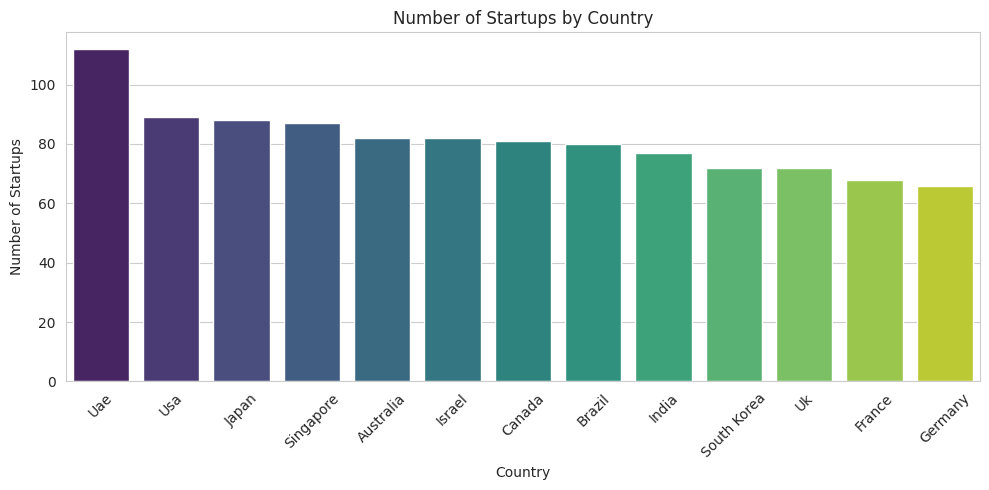

In [24]:
plt.figure(figsize=(10, 5))
order = df["Country"].value_counts().index
sns.countplot(data=df, x="Country", order=order, palette="viridis")
plt.title("Number of Startups by Country")
plt.xlabel("Country")
plt.ylabel("Number of Startups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Current Status Distribution

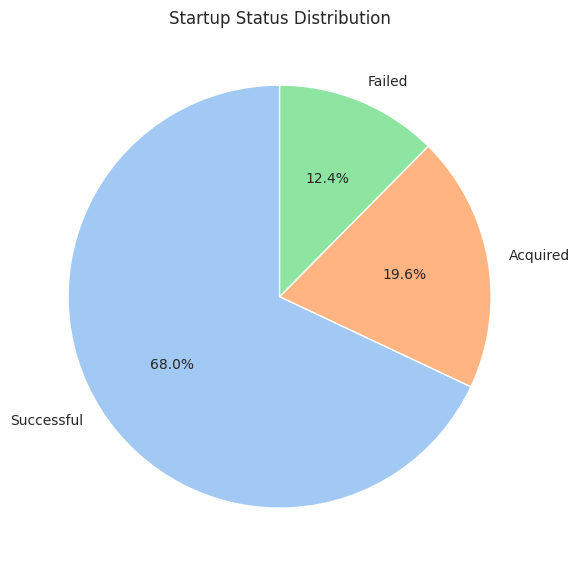

In [25]:
status_counts = df["Current Status"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"))
plt.title("Startup Status Distribution")
plt.tight_layout()
plt.show()

### 3. Startups Launched per Year

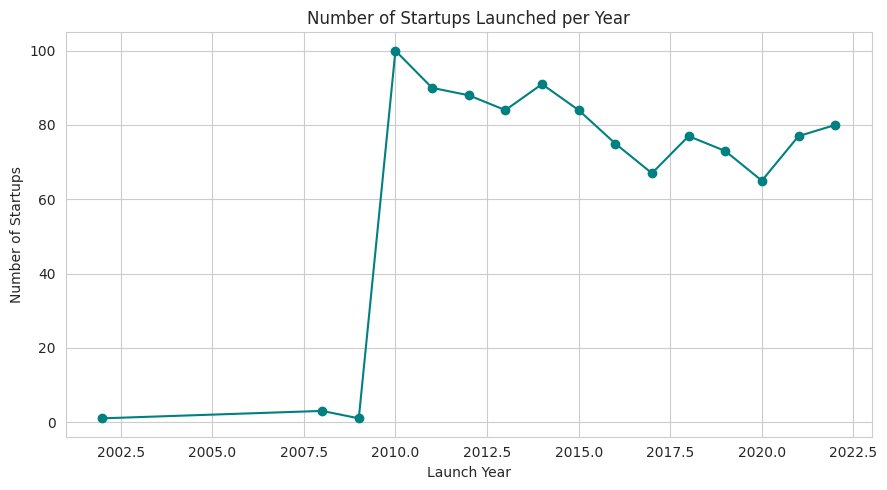

In [26]:
plt.figure()
df["Launch Year"].value_counts().sort_index().plot(kind="line", marker="o", color="teal")
plt.title("Number of Startups Launched per Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Startups")
plt.tight_layout()
plt.show()

### 4. Distribution of Year 3 Revenue

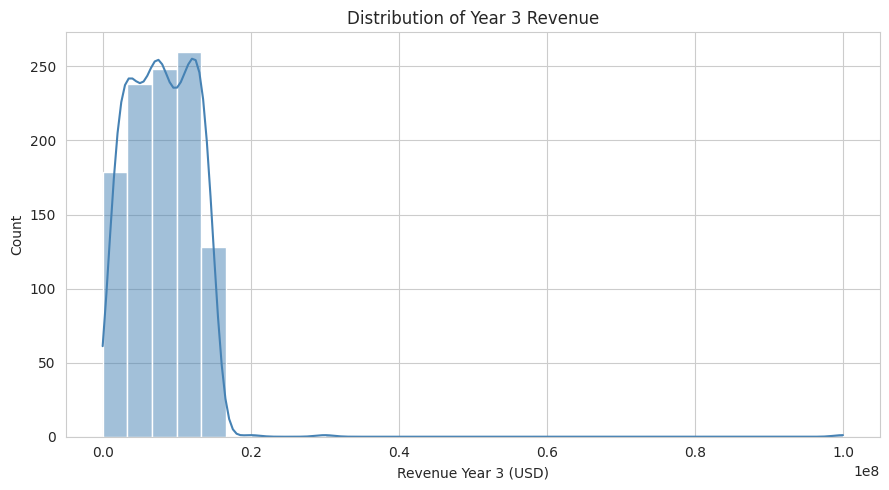

In [27]:
plt.figure()
sns.histplot(df["Revenue Year 3 (USD)"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Year 3 Revenue")
plt.xlabel("Revenue Year 3 (USD)")
plt.tight_layout()
plt.show()

### 5. Average Year 3 Revenue by Country

/tmp/ipykernel_536/884233620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rev_country.index, y=avg_rev_country.values, palette="crest")


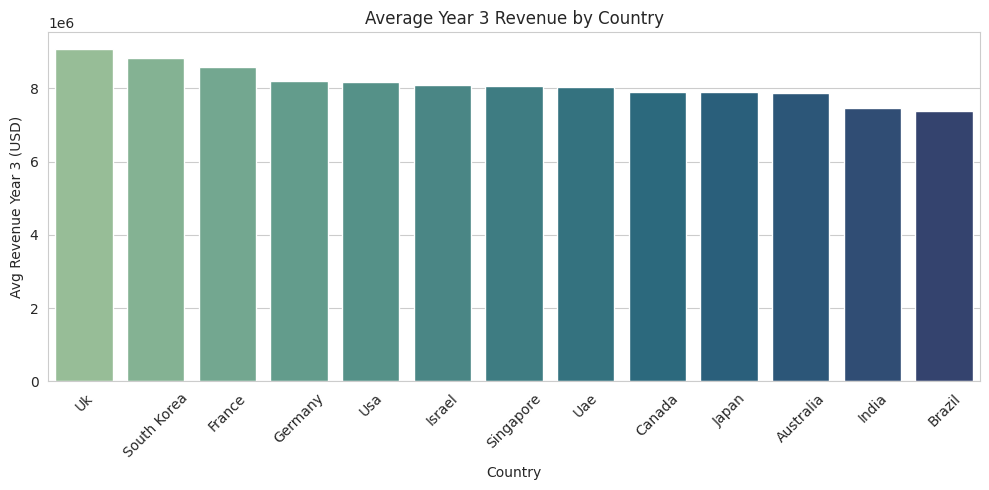

In [28]:
avg_rev_country = df.groupby("Country")["Revenue Year 3 (USD)"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_rev_country.index, y=avg_rev_country.values, palette="crest")
plt.title("Average Year 3 Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Avg Revenue Year 3 (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Average Revenue Trend (Year 1 vs Year 2 vs Year 3)

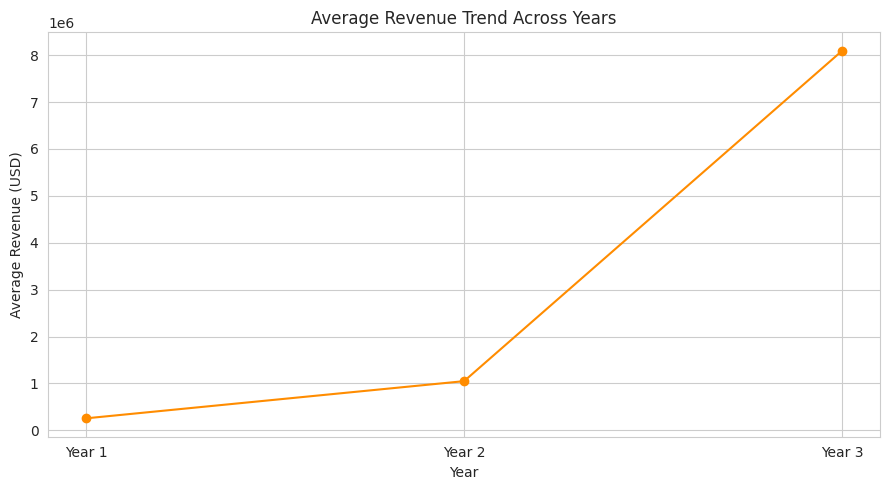

In [29]:
avg_by_year = df[["Revenue Year 1 (USD)", "Revenue Year 2 (USD)", "Revenue Year 3 (USD)"]].mean()
plt.figure()
plt.plot(["Year 1", "Year 2", "Year 3"], avg_by_year.values, marker="o", color="darkorange")
plt.title("Average Revenue Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Average Revenue (USD)")
plt.tight_layout()
plt.show()

### 7. Year 3 Revenue by Current Status (Boxplot)

/tmp/ipykernel_536/979872991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Current Status", y="Revenue Year 3 (USD)", palette="Set2")


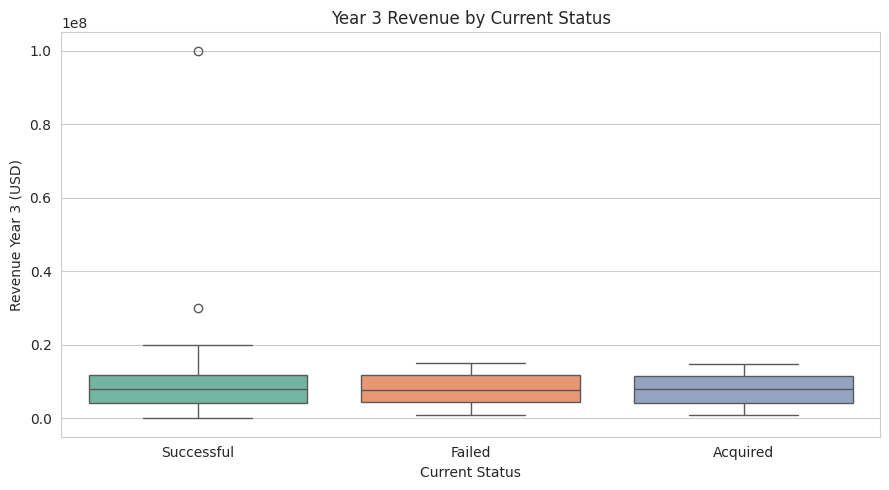

In [30]:
plt.figure()
sns.boxplot(data=df, x="Current Status", y="Revenue Year 3 (USD)", palette="Set2")
plt.title("Year 3 Revenue by Current Status")
plt.tight_layout()
plt.show()

### 8. Distribution of Founder Count

/tmp/ipykernel_536/2582802354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Founder Count", palette="magma")


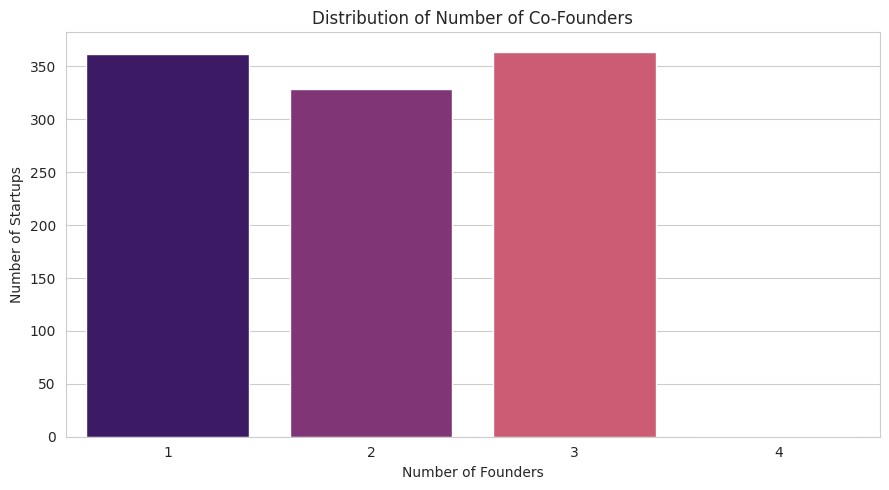

In [31]:
plt.figure()
sns.countplot(data=df, x="Founder Count", palette="magma")
plt.title("Distribution of Number of Co-Founders")
plt.xlabel("Number of Founders")
plt.ylabel("Number of Startups")
plt.tight_layout()
plt.show()

### 9. Country vs Status Heatmap

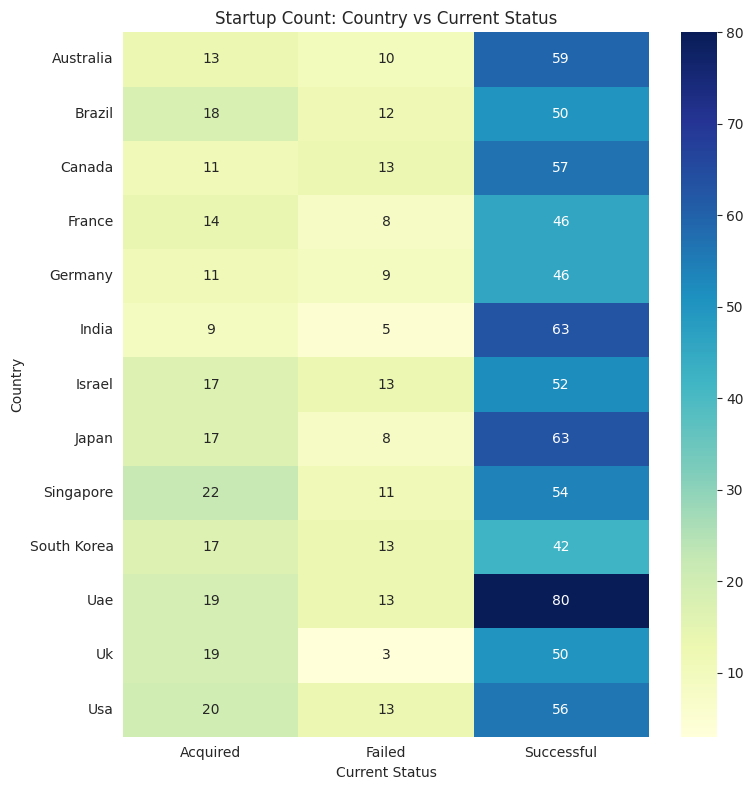

In [32]:
plt.figure(figsize=(8, 8))
sns.heatmap(country_status_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Startup Count: Country vs Current Status")
plt.tight_layout()
plt.show()

### 10. Correlation Heatmap of Numeric Features

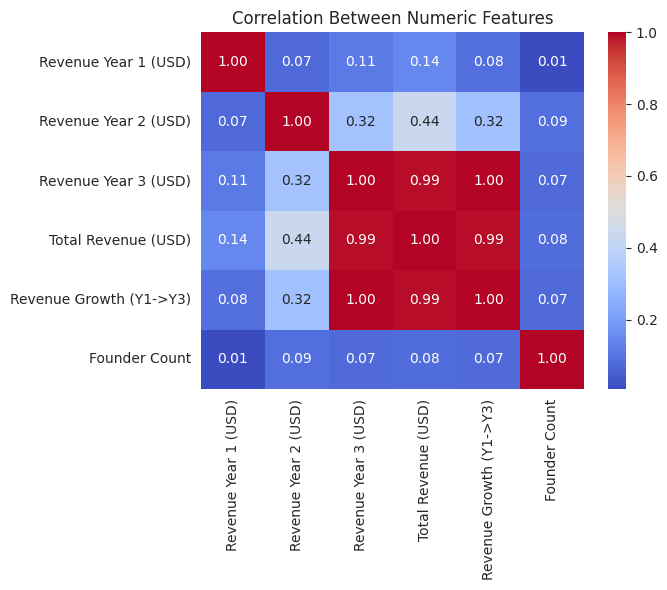

In [33]:
numeric_cols = ["Revenue Year 1 (USD)", "Revenue Year 2 (USD)", "Revenue Year 3 (USD)",
                "Total Revenue (USD)", "Revenue Growth (Y1->Y3)", "Founder Count"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

### 11. Top 10 Startups by Year 3 Revenue

/tmp/ipykernel_536/2936582902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="Name", x="Revenue Year 3 (USD)", palette="rocket")


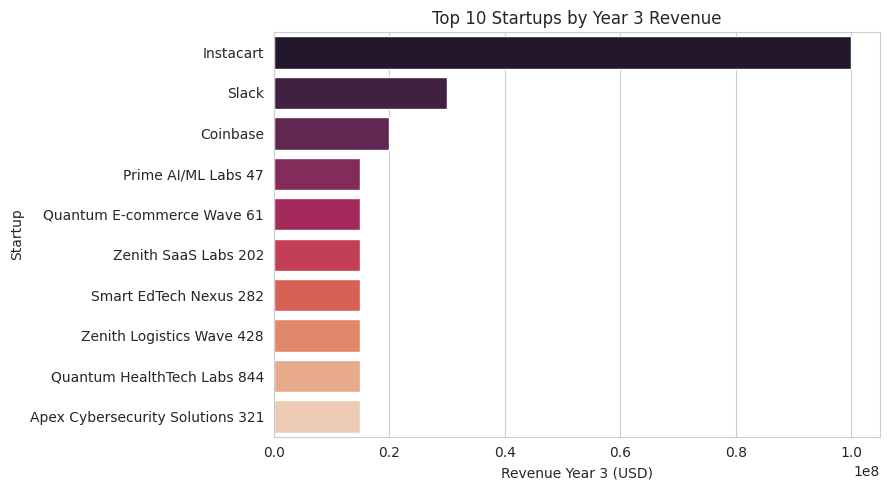

In [34]:
top10 = df.nlargest(10, "Revenue Year 3 (USD)")
plt.figure()
sns.barplot(data=top10, y="Name", x="Revenue Year 3 (USD)", palette="rocket")
plt.title("Top 10 Startups by Year 3 Revenue")
plt.xlabel("Revenue Year 3 (USD)")
plt.ylabel("Startup")
plt.tight_layout()
plt.show()

### 12. Revenue Growth (Year 1 to Year 3) Distribution

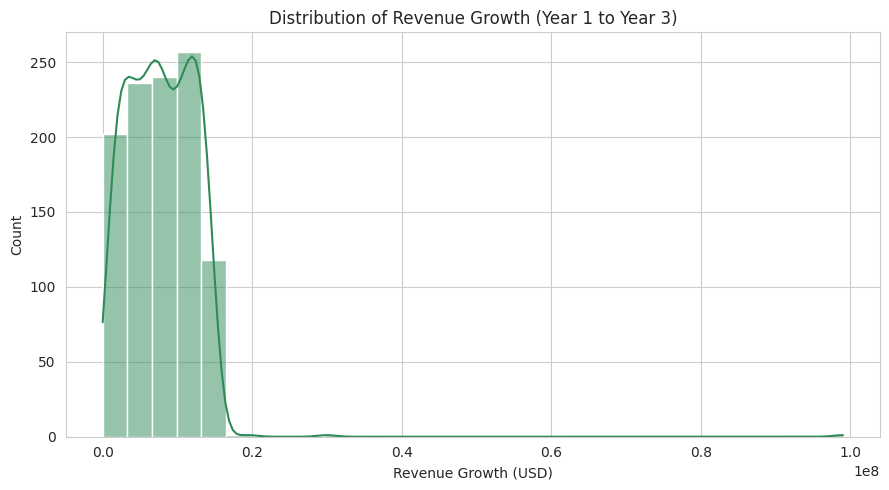

In [35]:
plt.figure()
sns.histplot(df["Revenue Growth (Y1->Y3)"], bins=30, kde=True, color="seagreen")
plt.title("Distribution of Revenue Growth (Year 1 to Year 3)")
plt.xlabel("Revenue Growth (USD)")
plt.tight_layout()
plt.show()

### 13. Founder Count vs Year 3 Revenue

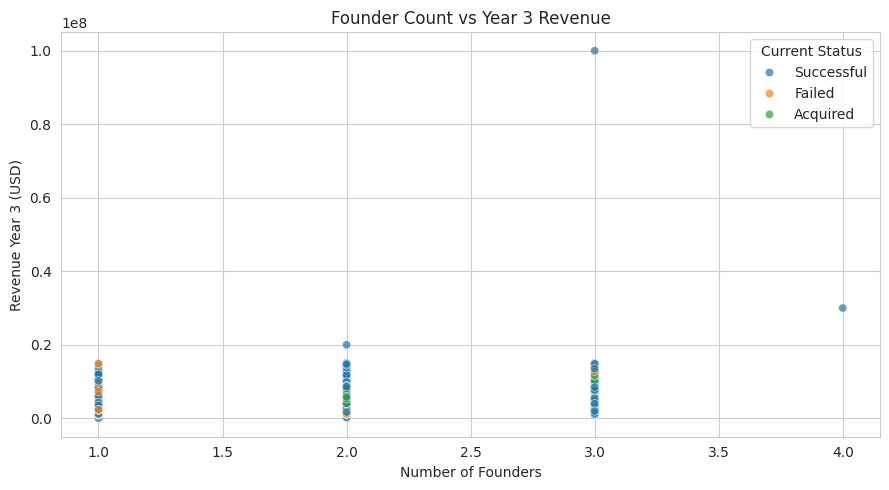

In [36]:
plt.figure()
sns.scatterplot(data=df, x="Founder Count", y="Revenue Year 3 (USD)", hue="Current Status", alpha=0.7)
plt.title("Founder Count vs Year 3 Revenue")
plt.xlabel("Number of Founders")
plt.ylabel("Revenue Year 3 (USD)")
plt.tight_layout()
plt.show()

### 14. Startups by Launch Year and Status (Stacked)

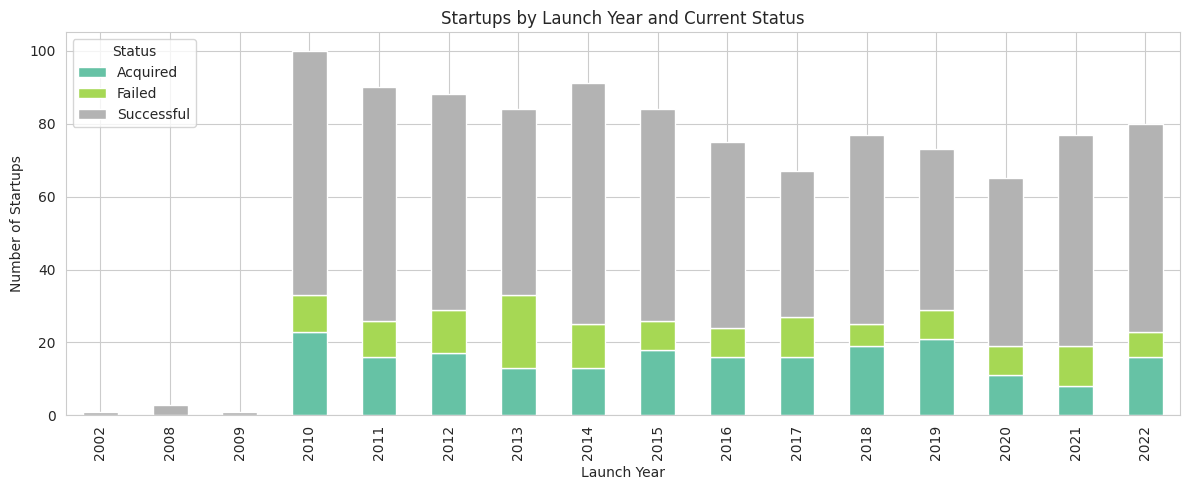

In [37]:
launch_status = pd.crosstab(df["Launch Year"], df["Current Status"])
launch_status.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="Set2")
plt.title("Startups by Launch Year and Current Status")
plt.xlabel("Launch Year")
plt.ylabel("Number of Startups")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

### 15. Average Revenue Growth by Country

/tmp/ipykernel_536/1899707691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_growth_country.index, y=avg_growth_country.values, palette="flare")


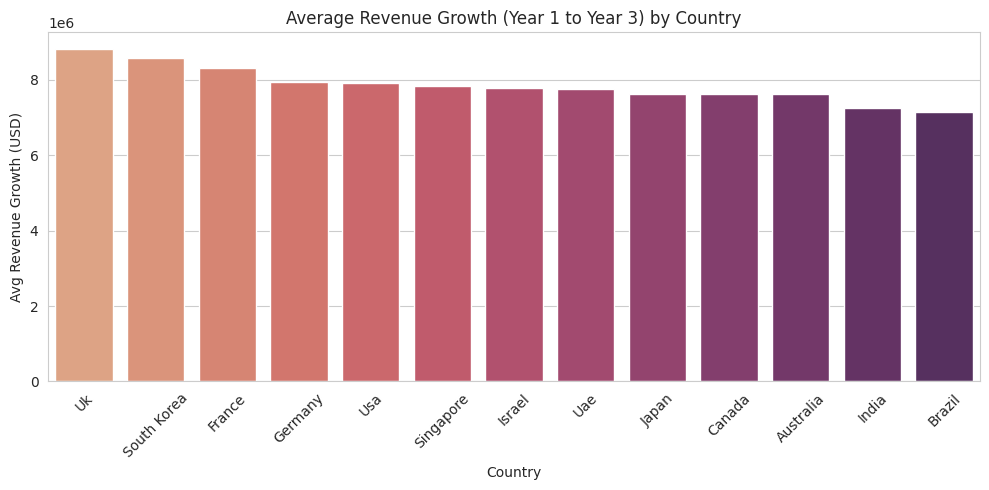

In [38]:
avg_growth_country = df.groupby("Country")["Revenue Growth (Y1->Y3)"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_growth_country.index, y=avg_growth_country.values, palette="flare")
plt.title("Average Revenue Growth (Year 1 to Year 3) by Country")
plt.xlabel("Country")
plt.ylabel("Avg Revenue Growth (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Summary

- Started from a clean dataset and verified it had no missing values, duplicates, or type issues.
- Deliberately introduced duplicates, missing values, whitespace/casing inconsistencies, and mixed
  data types to simulate real-world messy data.
- Rebuilt a full cleaning pipeline: dedup → fill missing values → normalize text → fix dtypes.
- Engineered features (founder count, total revenue, revenue growth) and confirmed the dataset was
  fully clean again before analysis.
- Produced 6 pivot tables and 15 charts covering distribution, comparison, trend, and correlation views.